In [25]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import joblib

from matplotlib.pyplot import xlabel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC

import seaborn as sns

# Loading Data

In [2]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [3]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [4]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

In [5]:
# Fit the label encoder to the classes (industry names)
le = LabelEncoder()
le.fit(df_train["industry"])
df_train["industry_encoded"] = le.transform(df_train["industry"])


In [6]:
le.classes_

array(['Automobiles & Components', 'Banks', 'Capital Goods',
       'Commercial & Professional Services',
       'Consumer Discretionary Distribution & Retail',
       'Consumer Durables & Apparel', 'Consumer Services',
       'Consumer Staples Distribution & Retail', 'Energy',
       'Equity Real Estate Investment Trusts (REITs)',
       'Financial Services', 'Food, Beverage & Tobacco',
       'Health Care Equipment & Services',
       'Household & Personal Products', 'Insurance', 'Materials',
       'Media & Entertainment',
       'Pharmaceuticals, Biotechnology & Life Sciences',
       'Real Estate Management & Development',
       'Semiconductors & Semiconductor Equipment', 'Software & Services',
       'Technology Hardware & Equipment', 'Telecommunication Services',
       'Transportation', 'Utilities'], dtype=object)

In [7]:
for industry, number in zip(le.classes_, range(len(le.classes_))):
    print(f"{industry} -> {number}")

Automobiles & Components -> 0
Banks -> 1
Capital Goods -> 2
Commercial & Professional Services -> 3
Consumer Discretionary Distribution & Retail -> 4
Consumer Durables & Apparel -> 5
Consumer Services -> 6
Consumer Staples Distribution & Retail -> 7
Energy -> 8
Equity Real Estate Investment Trusts (REITs) -> 9
Financial Services -> 10
Food, Beverage & Tobacco -> 11
Health Care Equipment & Services -> 12
Household & Personal Products -> 13
Insurance -> 14
Materials -> 15
Media & Entertainment -> 16
Pharmaceuticals, Biotechnology & Life Sciences -> 17
Real Estate Management & Development -> 18
Semiconductors & Semiconductor Equipment -> 19
Software & Services -> 20
Technology Hardware & Equipment -> 21
Telecommunication Services -> 22
Transportation -> 23
Utilities -> 24


In [8]:
le = LabelEncoder()
le.fit(df_val["industry"])
df_val["industry_encoded"] = le.transform(df_val["industry"])

In [9]:
le.classes_

array(['Automobiles & Components', 'Banks', 'Capital Goods',
       'Commercial & Professional Services',
       'Consumer Discretionary Distribution & Retail',
       'Consumer Durables & Apparel', 'Consumer Services',
       'Consumer Staples Distribution & Retail', 'Energy',
       'Equity Real Estate Investment Trusts (REITs)',
       'Financial Services', 'Food, Beverage & Tobacco',
       'Health Care Equipment & Services',
       'Household & Personal Products', 'Insurance', 'Materials',
       'Media & Entertainment',
       'Pharmaceuticals, Biotechnology & Life Sciences',
       'Real Estate Management & Development',
       'Semiconductors & Semiconductor Equipment', 'Software & Services',
       'Technology Hardware & Equipment', 'Telecommunication Services',
       'Transportation', 'Utilities'], dtype=object)

In [10]:
for industry, number in zip(le.classes_, range(len(le.classes_))):
    print(f"{industry} -> {number}")

Automobiles & Components -> 0
Banks -> 1
Capital Goods -> 2
Commercial & Professional Services -> 3
Consumer Discretionary Distribution & Retail -> 4
Consumer Durables & Apparel -> 5
Consumer Services -> 6
Consumer Staples Distribution & Retail -> 7
Energy -> 8
Equity Real Estate Investment Trusts (REITs) -> 9
Financial Services -> 10
Food, Beverage & Tobacco -> 11
Health Care Equipment & Services -> 12
Household & Personal Products -> 13
Insurance -> 14
Materials -> 15
Media & Entertainment -> 16
Pharmaceuticals, Biotechnology & Life Sciences -> 17
Real Estate Management & Development -> 18
Semiconductors & Semiconductor Equipment -> 19
Software & Services -> 20
Technology Hardware & Equipment -> 21
Telecommunication Services -> 22
Transportation -> 23
Utilities -> 24


In [11]:
y_train = df_train["industry_encoded"]
y_val =  df_val["industry_encoded"]

In [12]:
# Returns "True" if both arrays have the same labels.
np.array_equal(np.unique(y_train), np.unique(y_val))

True

# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

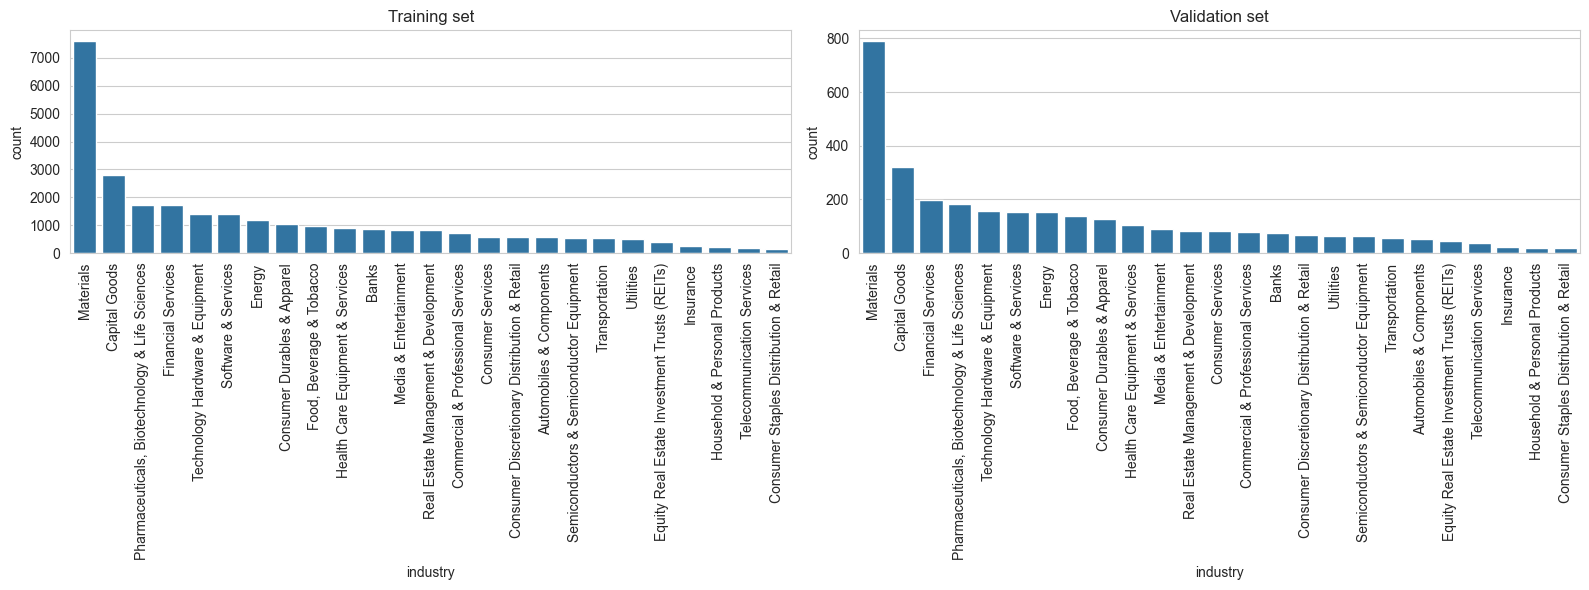

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, df, title in zip(axes, [df_train, df_val], ["Training set", "Validation set"]):
    sns.countplot(
        data=df,
        x="industry",
        order=df["industry"].value_counts().index,
        ax=ax
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The industry _Materials_ is overrepresented towards all other industries. Due to this issue, a classification model will recocnise companys of the label _Materials_ better than others. Nevertheless, the distibution is more or less the same for both train and val datasets.

### PCA - Dimensionality reduction and visualization

In [14]:
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)


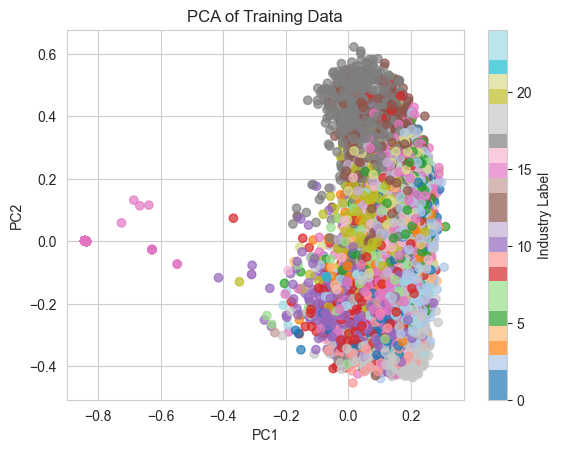

In [15]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=df_train["industry_encoded"], cmap=plt.get_cmap("tab20", len(le.classes_)), alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Training Data")
plt.colorbar(label="Industry Label")
plt.show()

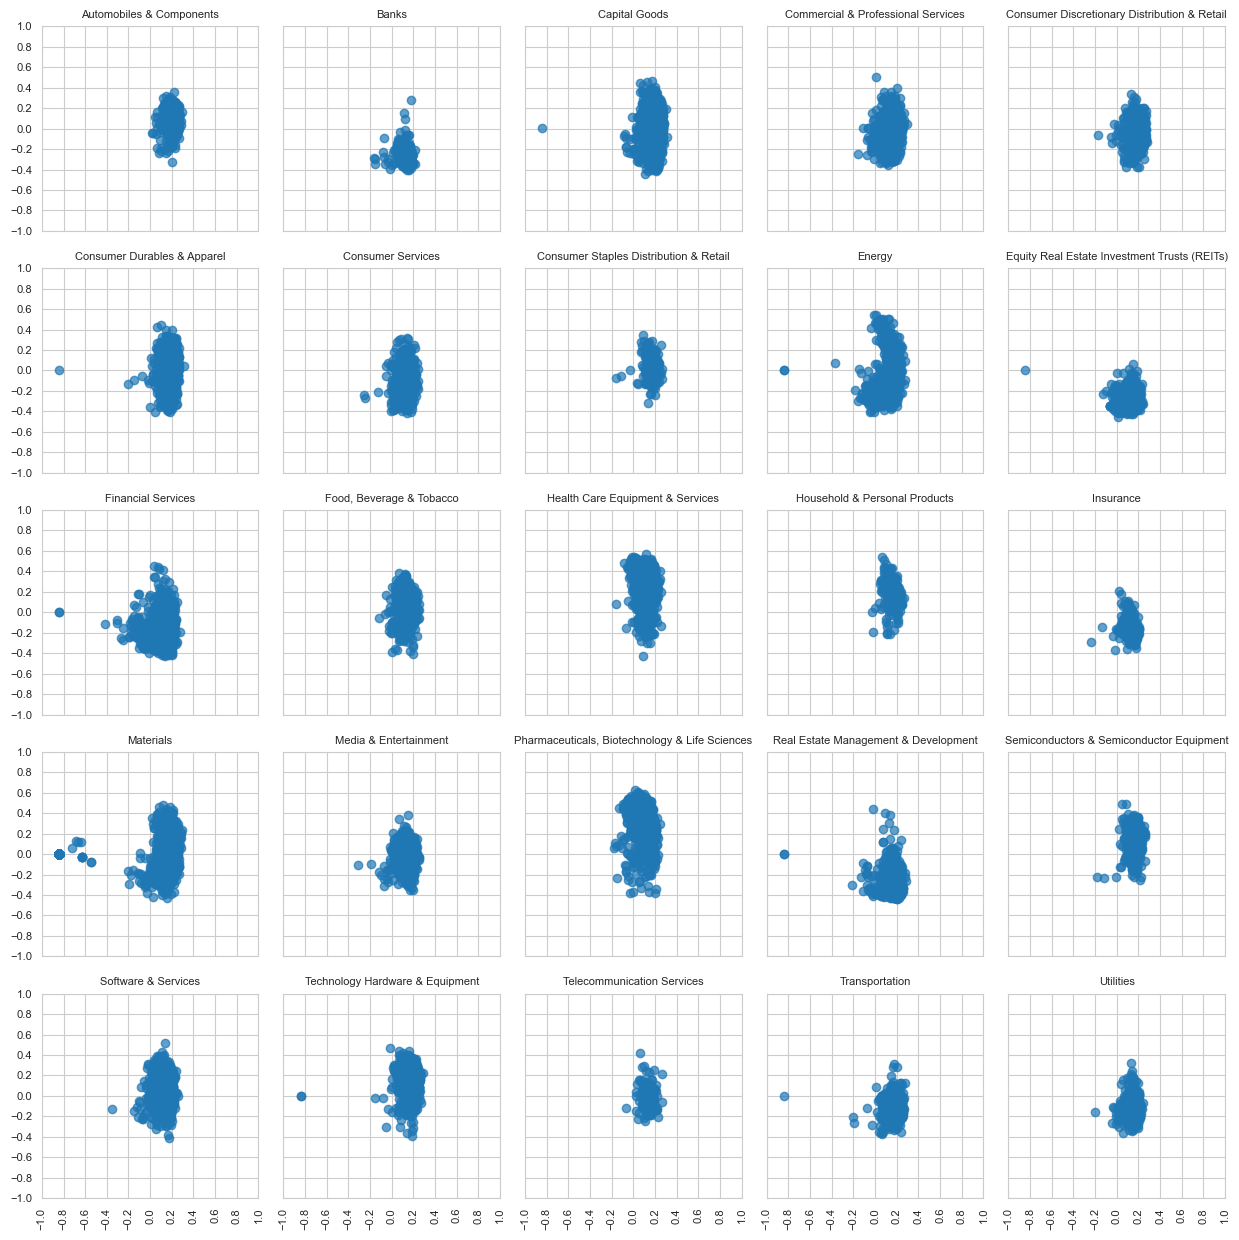

In [16]:
num_classes = len(le.classes_)  # 25

# Grid for subplots (5x5)
n_cols = 5
n_rows = int(np.ceil(num_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.5, n_rows*2.5), sharex=True, sharey=True)

axes = axes.flatten()  # Flatten in order to iterate more efficiently

for i, industry_label in enumerate(le.classes_):
    ax = axes[i]
    # All points of this industry
    idx = df_train["industry"] == industry_label
    ax.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], alpha=0.7)
    ax.set_title(industry_label, fontsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_yticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.tight_layout()
plt.show()


# Fitting and comparing Classifier Models

## Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots!

## Logistic Regression

In [17]:
# Logistic Regression Classification
clf = LogisticRegression(random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [18]:
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_pred, average="weighted"):.4f}")

Accuracy: 0.7720
F1 Score (weighted): 0.7663


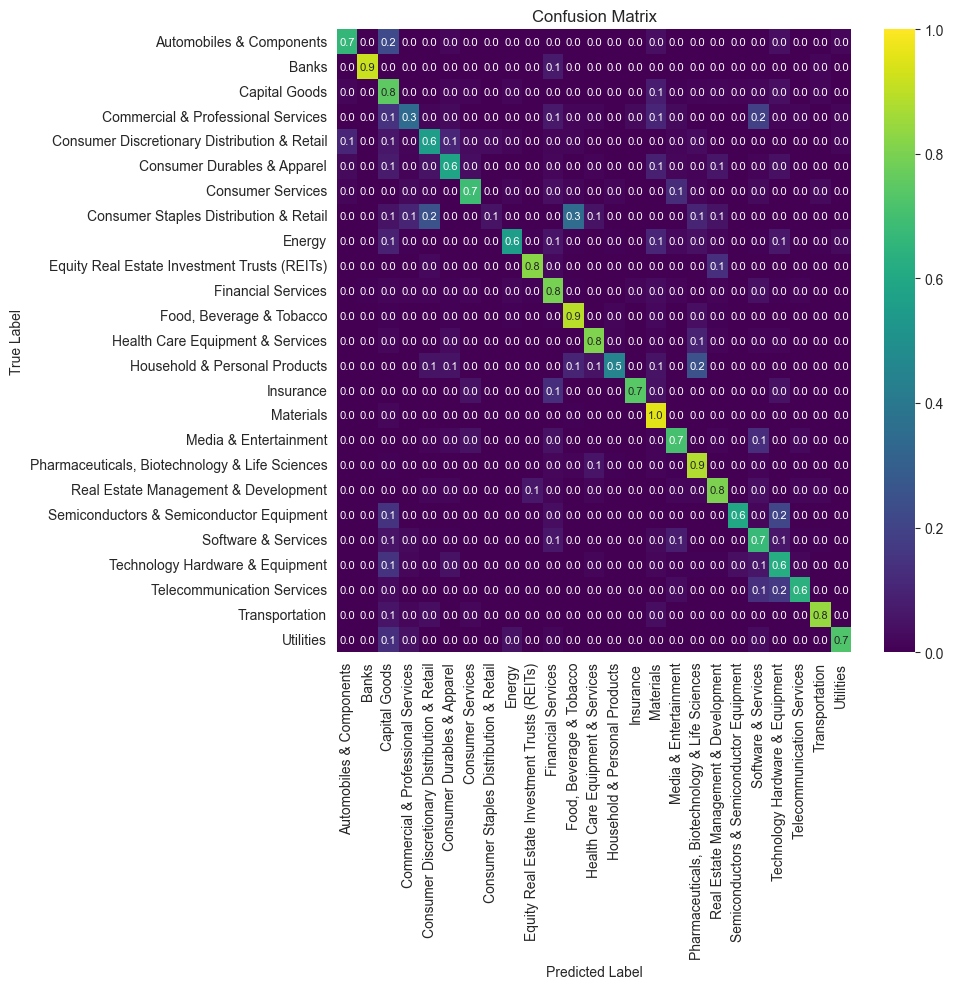

In [19]:
cm = confusion_matrix(y_val, y_pred, normalize="true")

plt.figure(figsize=(10, 10))
sns.heatmap(cm,
            annot=True,
            cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1,
            fmt=".1f",
            annot_kws={"fontsize": 8}
            )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## kNN Classifier

In [20]:
neigh = KNeighborsClassifier(n_neighbors=15, weights="distance", p=1, metric="euclidean")
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_val)
neigh.fit(X_train, y_train)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2032.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\leoni\Documents\UZH\Foundations of Data Science\Practical_1\venv\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2032.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2032.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13

,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [21]:
y_pred_knn = neigh.predict(X_val)

In [22]:
print(f"Accuracy: {accuracy_score(y_val, y_pred_knn):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_pred_knn, average="weighted"):.4f}")

Accuracy: 0.7755
F1 Score (weighted): 0.7698


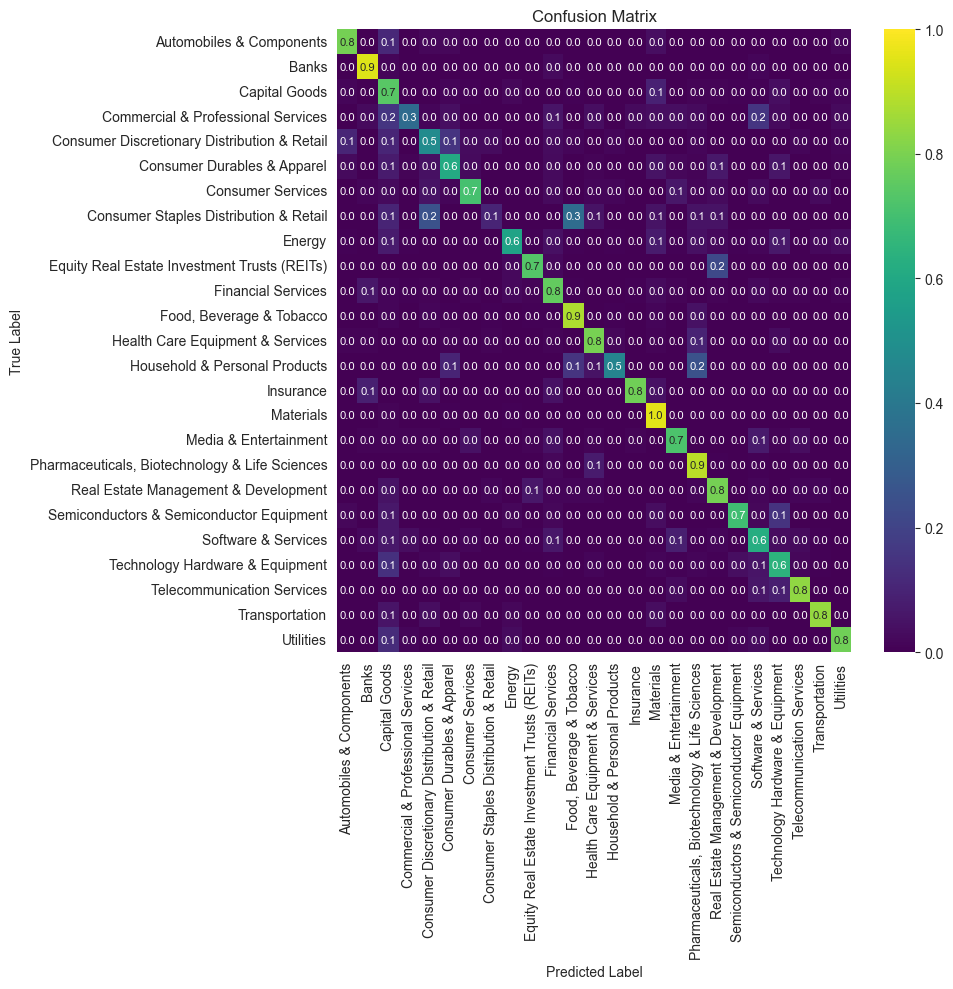

In [23]:
cm = confusion_matrix(y_val, y_pred_knn, normalize="true")

plt.figure(figsize=(10, 10))
sns.heatmap(cm,
            annot=True,
            cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1,
            fmt=".1f",
            annot_kws={"fontsize": 8}
            )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

### Support Vector Machine (SVM)

In [24]:
svc = SVC(random_state=42, probability=True, verbose=True, class_weight="balanced")
svc.fit(X_train, y_train)

[LibSVM]

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,True


In [26]:
# Safe the model
joblib.dump(svc, "svc_model.pkl")

['svc_model.pkl']

In [27]:
y_pred_svc = svc.predict(X_val)

In [28]:
print(f"Accuracy: {accuracy_score(y_val, y_pred_svc):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_pred_svc, average="weighted"):.4f}")

Accuracy: 0.7723
F1 Score (weighted): 0.7734


In [31]:
y_proba = svc.predict_proba(X_val)

[[9.13464196e-04 4.88945007e-04 7.82351193e-01 5.74838079e-02
  3.09128071e-03 1.40503007e-02 1.14564970e-03 4.16352364e-04
  8.15438428e-03 3.77976132e-04 5.70726078e-03 2.44323235e-03
  2.03176175e-03 6.04655007e-04 4.18377777e-04 1.37349816e-02
  2.45751903e-03 1.14931307e-03 3.29359858e-03 2.84462674e-03
  2.76365709e-03 2.28111339e-02 5.92353309e-04 9.97183048e-04
  6.96769924e-02]
 [7.51567333e-04 1.18657733e-03 1.46618178e-02 2.49652305e-03
  8.05129181e-03 2.54496717e-03 2.01073979e-02 1.73270827e-04
  1.12978989e-02 4.16949363e-04 1.20903264e-02 5.62401384e-04
  3.36475351e-04 1.50829819e-04 1.12105024e-03 1.19263573e-03
  2.31269741e-03 2.84082083e-04 2.09549608e-02 9.33540407e-05
  2.78676521e-03 1.27107134e-03 5.70893351e-04 8.93849494e-01
  7.34701569e-04]
 [1.17540762e-04 1.14821358e-05 4.07925475e-03 4.81752584e-04
  7.77831636e-05 5.15073389e-04 2.56627513e-05 1.21421347e-05
  1.26359918e-03 7.13840267e-06 1.35313558e-04 1.72874576e-04
  1.88892820e-05 1.61602548e-04 6.

In [40]:
print(y_pred_svc[254:255])
print(y_proba[254:255])

[2]
[[7.16772831e-03 1.23139951e-05 8.38831661e-01 5.07046065e-03
  5.20026988e-04 1.14731131e-02 6.20307448e-04 2.26099697e-05
  5.55676733e-03 8.66443402e-06 5.40449686e-04 2.14409236e-05
  2.81528363e-04 6.92760652e-05 5.70744567e-05 5.97920344e-04
  1.40081607e-04 8.33107750e-05 1.58885743e-04 1.00655266e-03
  3.30865537e-03 1.21310875e-01 1.12081996e-04 3.00820165e-03
  2.00115109e-05]]


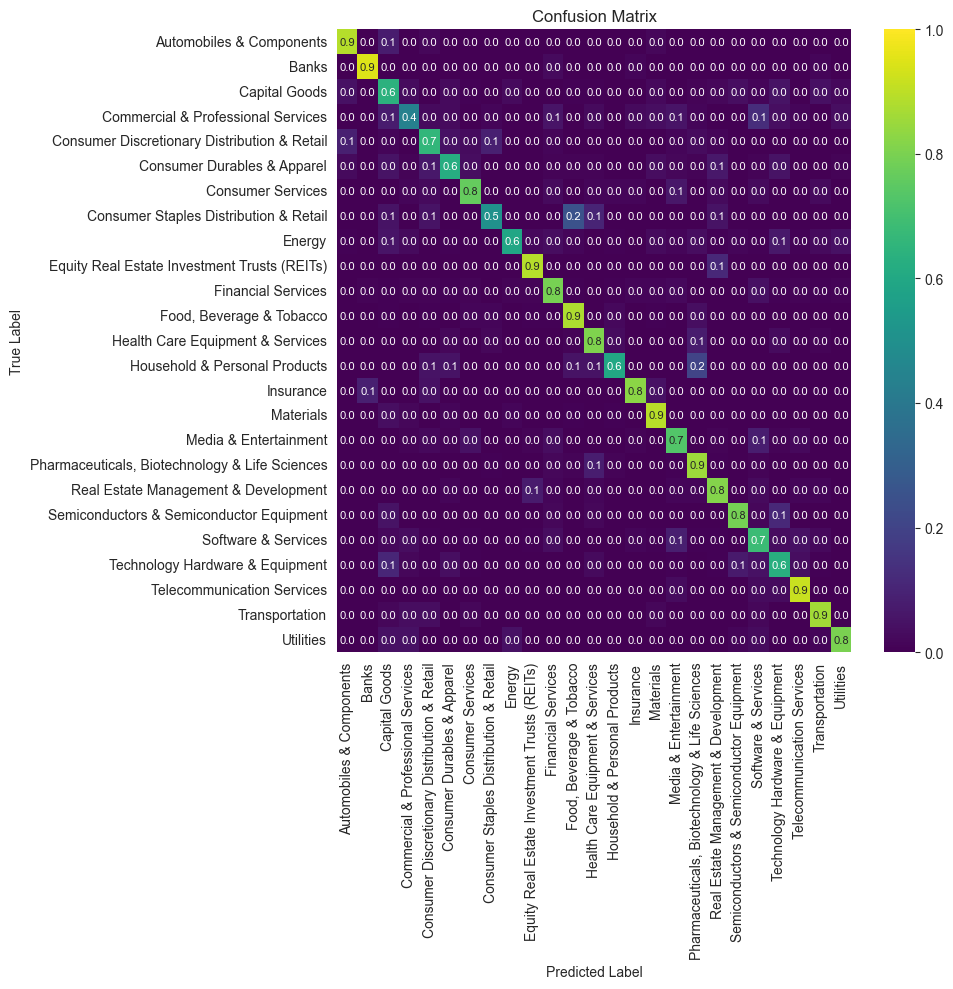

In [29]:
cm = confusion_matrix(y_val, y_pred_svc, normalize="true")

plt.figure(figsize=(10, 10))
sns.heatmap(cm,
            annot=True,
            cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1,
            fmt=".1f",
            annot_kws={"fontsize": 8}
            )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    # Weight all predictions, not just positives
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1

In [ ]:
confidence_weighted_f1(y_val, y_pred, 0.05)